# 0. Connect Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Import Libraries

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.backend import clear_session

# 2. Load Split Dataset

In [3]:
import sys

project_dir = "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification"
sys.path.append(project_dir)

from utils import load_animals10_datasets

train_dataset, val_dataset, test_dataset, class_names = load_animals10_datasets()

Using Colab cache for faster access to the 'animals10' dataset.


### Check Data

In [4]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

print(class_names)

(32, 128, 128, 3)
(32, 10)
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


# 3. Define Model

In [5]:
from keras.backend import clear_session
clear_session()

## 3.1 Phase 1 Load MobileNetV2 and Freeze Base Model

In [6]:
from tensorflow.keras.applications import MobileNetV2

num_classes = 10
input_shape= (128, 128, 3)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=input_shape
)

base_model.trainable = False

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Rescaling(2.0, offset=-1),

        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 4. Compile and Train Model

In [7]:
import time
from keras.optimizers import Adam

epochs = 30
my_opt1 = Adam(learning_rate=0.0001)
my_opt2 = Adam(learning_rate=0.00001)

model.compile(
    loss="categorical_crossentropy",
    optimizer=my_opt1,
    metrics=['accuracy']
)

early_stop1 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Track train time: starting timing
start_time = time.time()

history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stop1]
)

# Track train time: end timing
end_time = time.time()

phase1_time = end_time - start_time

print(f"Phase 1 training time: {phase1_time:.2f} seconds")
print(f"Phase 1 training time: {phase1_time / 60:.2f} minutes")

Epoch 1/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 165s 222ms/step - accuracy: 0.8004 - loss: 0.6705 - val_accuracy: 0.9312 - val_loss: 0.2341
Epoch 2/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - accuracy: 0.9242 - loss: 0.2526 - val_accuracy: 0.9396 - val_loss: 0.2030
Epoch 3/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - accuracy: 0.9378 - loss: 0.2056 - val_accuracy: 0.9446 - val_loss: 0.1861
Epoch 4/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.9475 - loss: 0.1742 - val_accuracy: 0.9461 - val_loss: 0.1805
Epoch 5/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 44s 46ms/step - accuracy: 0.9534 - loss: 0.1496 - val_accuracy: 0.9473 - val_loss: 0.1771
Epoch 6/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.9590 - loss: 0.1342 - val_accuracy: 0.9488 - val_loss: 0.1723
Epoch 7/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.9623 - loss: 0.1206 - val_accuracy: 0.9507 - val_loss: 0.1698
Epoch 8/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.9664 - loss: 0.1087 

## 5. Evaluate Phase 1

In [8]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Phase 1 Test loss:", test_loss)
print("Phase 1 Test accuracy:", test_accuracy)

82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 197ms/step - accuracy: 0.9465 - loss: 0.1771
Phase 1 Test loss: 0.17705023288726807
Phase 1 Test accuracy: 0.9465240836143494


# 6. Phase 2 Unfreeze and Fine-tune

In [9]:
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False
for layer in base_model.layers[100:]:
    layer.trainable = True

trainable_count = sum([layer.trainable for layer in base_model.layers])
print("Trainable layers in base_model:", trainable_count)
print("Total layers in base_model:", len(base_model.layers))

Trainable layers in base_model: 54
Total layers in base_model: 154


# 7. Re-compile With Very Small Learning Rate

In [10]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=my_opt2,
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Track train time: starting timing
start_time = time.time()

history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stop2]
)

# Track train time: end timing
end_time = time.time()

phase2_time = end_time - start_time

print(f"Phase 2 training time: {phase2_time:.2f} seconds")
print(f"Phase 2 training time: {phase2_time / 60:.2f} minutes")

Epoch 1/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 73s 73ms/step - accuracy: 0.9098 - loss: 0.2793 - val_accuracy: 0.9469 - val_loss: 0.1749
Epoch 2/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - accuracy: 0.9384 - loss: 0.1887 - val_accuracy: 0.9477 - val_loss: 0.1710
Epoch 3/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9493 - loss: 0.1529 - val_accuracy: 0.9481 - val_loss: 0.1732
Epoch 4/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - accuracy: 0.9561 - loss: 0.1342 - val_accuracy: 0.9519 - val_loss: 0.1710
Epoch 5/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.9639 - loss: 0.1107 - val_accuracy: 0.9503 - val_loss: 0.1750
Phase 2 training time: 201.58 seconds
Phase 2 training time: 3.36 minutes


# 8. Evaluate Model

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    true_labels = np.argmax(labels.numpy(), axis=1)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(true_labels)
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"Test accuracy: {accuracy}")
print(f"Test precision: {precision}")
print(f"Test recall: {recall}")
print(f"Confusion Matrix: \n {cm}")

Test accuracy: 0.9438502673796791
Test precision: 0.9401233623695621
Test recall: 0.9352184171909969
Confusion Matrix: 
 [[460  10   3   0   2   5   4   1   0   2]
 [  7 245   0   0   1   1   5   3   0   0]
 [  0   0 137   0   1   0   0   4   1   2]
 [  0   0   1 202   0   0   1   0   4   3]
 [  5   1   0   0 300   0   0   0   1   3]
 [ 11   1   0   0   0 151   0   1   1   2]
 [  4  13   1   1   3   1 156   7   0   0]
 [  6   5   1   0   0   1   5 164   0   0]
 [  0   0   0   6   0   0   0   0 475   1]
 [  2   0   0   0   2   1   0   0   0 181]]


# 9.Plot Loss and Accuracy

In [13]:
history_phase2.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

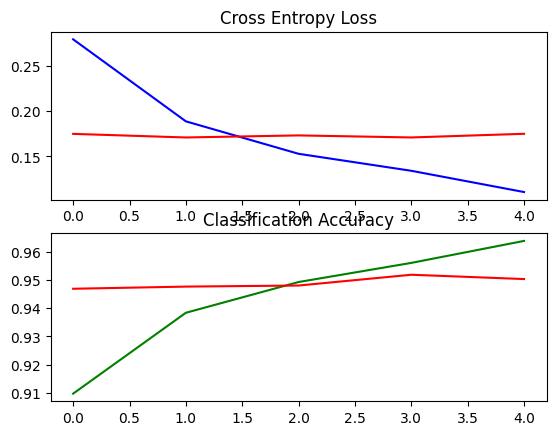

In [14]:
import matplotlib.pyplot as plt

plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history_phase2.history['loss'], color='blue', label='train')
plt.plot(history_phase2.history['val_loss'], color='red', label='validation')

plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history_phase2.history['accuracy'], color='green', label='train')
plt.plot(history_phase2.history['val_accuracy'], color='red', label='validation')
plt.show()

# 9.2 Plot Comfusion Matrix

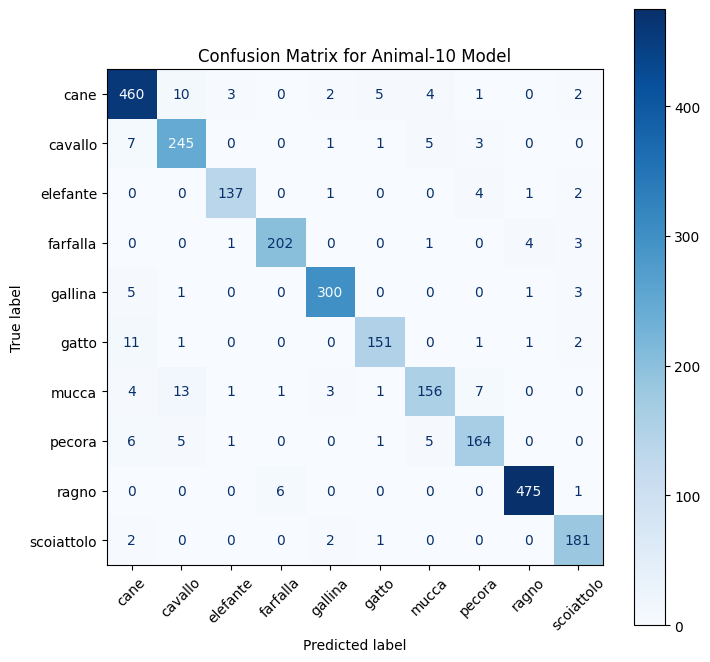

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix for Animal-10 Model")
plt.show()

# 10. Save Model

In [16]:
model.save("/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_7_transfer_learning.keras")

print("Model Saved")

Model Saved


In [17]:
# how to import model when needed

'''
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_7_transfer_learning.keras"
)
'''

'\nimport tensorflow as tf\n\nmodel = tf.keras.models.load_model(\n    "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_7_transfer_learning.keras"\n)\n'